The Data

In [3]:
# Packages
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import warnings
import pandas as pd
from IPython.display import display

from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.utils import resample

from time import perf_counter

import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)   # 64-bit floats, as in numpy

In [4]:
def runge(x):
    return 1.0 / (1.0 + 25.0 * x**2)

def design_matrix(x, degree, intercept=True):
    # polynomial features [1, x, x^2, ..., x^degree] (drop the 1 if intercept=False)
    start = 0 if intercept else 1
    return np.vstack([x**p for p in range(start, degree + 1)]).T

rng = np.random.default_rng(2026)
n = 350
#ENDRET(0)
# Samme støynivå som i LinearRegression.ipynb.
sigma = 0.25
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

xx = np.linspace(-1, 1, n)
#plt.plot(xx, runge(xx), color="#004488", label="Runge's function")
#plt.scatter(x, y, s=12, color="#BB5566", label=rf"data, $\sigma={sigma}$")
#plt.xlabel("x"); plt.ylabel("y"); plt.legend(frameon=False)
#plt.show()

# e: Gradient Descent

In [5]:
degree, lmbda = 5, 1e-2
X = design_matrix(x, degree)
theta0 = rng.normal(size=X.shape[1])

def closed_form(X, y, lam=0.0):
    # Samme kost som GD: MSE + lam / n * sum(theta[1:]**2).
    X, y = np.asarray(X), np.asarray(y)
    if lam == 0.0:
        return np.linalg.pinv(X) @ y
    P = np.eye(X.shape[1])
    P[0, 0] = 0.0  # Ikke straff konstantleddet.
    return np.linalg.solve(X.T @ X + lam * P, X.T @ y)

def cost_ols(theta, X, y):
    return jnp.mean((y - X @ theta)**2)

def cost_ridge(theta, X, y, lmbda): # [1:] vil ikke straffe intercept
    return (
        jnp.mean((y - X @ theta)**2)
        + (lmbda / len(y)) * jnp.sum(theta[1:]**2)
    )

# gradients by automatic differentiation (with respect to argument 0 = theta)
grad_ols_ad = jax.grad(cost_ols)
grad_ridge_ad = jax.grad(cost_ridge)

# the same gradients by hand
grad_ols_analytic = 2.0 / len(y) * X.T @ (X @ theta0 - y)
penalty = theta0.copy()
penalty[0] = 0.0  # Samme unntak for konstantleddet som i cost_ridge.
grad_ridge_analytic = grad_ols_analytic + (2.0 * lmbda / len(y)) * penalty

print("OLS   max |AD - analytic| =", np.max(np.abs(grad_ols_ad(theta0, X, y) - grad_ols_analytic)))
print("Ridge max |AD - analytic| =", np.max(np.abs(grad_ridge_ad(theta0, X, y, lmbda) - grad_ridge_analytic)))

#ENDRET(1)
# Disse grensene gjelder hele det uskalerte datasettet.
H = 2.0 / len(y) * X.T @ X
eig_initial = np.linalg.eigvalsh(H)

print(
    "OLS, hele uskalerte datasettet: eta-grense =",
    2.0 / eig_initial.max(),
)
print(
    "OLS, hele uskalerte datasettet: optimal verste-fall-eta =",
    2.0 / (eig_initial.max() + eig_initial.min()),
)


OLS   max |AD - analytic| = 3.3306690738754696e-16
Ridge max |AD - analytic| = 3.3306690738754696e-16
OLS, hele uskalerte datasettet: eta-grense = 0.8688214533500517
OLS, hele uskalerte datasettet: optimal verste-fall-eta = 0.8683450276617705


In [6]:

def gradient_e(theta, X, y, lmb):
    """Analytisk gradient evaluert på NYTT for hver verdi av theta."""
    penalty = theta.copy()                # Ikke endre theta ved et uhell.
    penalty[0] = 0.0                      # Ingen Ridge-straff på konstantleddet.
    return (2.0 / len(y)) * (X.T @ (X @ theta - y) + lmb * penalty)


def gradient_descent_e(gradient, theta_start, eta, max_iter=30000, tol=1e-8):
    """Bruk hele treningssettets gradient og samme eta gjennom hele kjøringen.

    gradient er en funksjon av theta. Returnerer parametre, parameterhistorikk
    og status. tol gjelder den euklidske normen av gradienten, ikke testfeilen.
    """
    theta = np.array(theta_start, dtype=float, copy=True)
    history = [theta.copy()]
    # Én runde i løkken er én parameteroppdatering (ingen mini-batcher).
    for iteration in range(max_iter):
        grad = np.asarray(gradient(theta))
        if not np.all(np.isfinite(grad)) or np.linalg.norm(theta) > 1e12:
            return theta, np.asarray(history), "divergerer"
        if np.linalg.norm(grad) <= tol:
            return theta, np.asarray(history), "konvergert"
        
        theta = theta - eta * grad        # Selve gradient descent-steget.
        history.append(theta.copy())     # copy bevarer verdien fra dette steget.

    status = "konvergert" if np.linalg.norm(gradient(theta)) <= tol else "maks iterasjoner"
    return theta, np.asarray(history), status

In [7]:
# Skalering
# Grad 5 gjør det lett å se konvergens; prøv senere f.eks. grad 10 og 15.
#ENDRET(2)
# Valgte verdier for konvergenseksperimentet, ikke en modellutvelgelse.
degree_e = 5
lmb_e = 0.01
X = design_matrix(x, degree_e)  # Bygg matrisen for graden valgt her.
Xe_train, Xe_test, ye_train, ye_test = train_test_split(
    X, y, test_size=0.3, random_state=2026
)
# Skalering læres KUN fra treningssettet. Konstantkolonnen beholdes som 1.
mean_e, std_e = Xe_train.mean(axis=0), Xe_train.std(axis=0)
mean_e[0], std_e[0] = 0.0, 1.0
Xe_train = (Xe_train - mean_e) / std_e
Xe_test = (Xe_test - mean_e) / std_e
n_e, p_e = Xe_train.shape
P_e = np.eye(p_e)                         # Diagonal straffematrise.
P_e[0, 0] = 0.0
start_e = np.random.default_rng(2026).normal(size=p_e)
Xj_e, yj_e = jnp.asarray(Xe_train), jnp.asarray(ye_train) # Yessir!

#ENDRET(3)
# Sammenlign NumPy-gradient og AD på den skalerte treningsmatrisen.
check_rng_e = np.random.default_rng(2027)
check_thetas_e = [start_e, check_rng_e.normal(size=p_e)]

for check_index, theta_check in enumerate(check_thetas_e):
    analytic_ols = gradient_e(theta_check, Xe_train, ye_train, 0.0)
    analytic_ridge = gradient_e(theta_check, Xe_train, ye_train, lmb_e)

    ad_ols = np.asarray(grad_ols_ad(theta_check, Xj_e, yj_e))
    ad_ridge = np.asarray(
        grad_ridge_ad(theta_check, Xj_e, yj_e, lmb_e)
    )

    print(
        f"Kontroll {check_index}, OLS: maks gradientavvik = "
        f"{np.max(np.abs(ad_ols - analytic_ols)):.3e}"
    )
    print(
        f"Kontroll {check_index}, Ridge: maks gradientavvik = "
        f"{np.max(np.abs(ad_ridge - analytic_ridge)):.3e}"
    )


Kontroll 0, OLS: maks gradientavvik = 1.332e-15
Kontroll 0, Ridge: maks gradientavvik = 8.882e-16
Kontroll 1, OLS: maks gradientavvik = 4.441e-15
Kontroll 1, Ridge: maks gradientavvik = 4.441e-15


In [8]:
# Beregner eta, kappa verdier utifra egenverdiene til Hessian
def Hessian_OLS(X, n):
    H_OLS = (2 / n) * X.T @ X
    return H_OLS

def Hessian_R(X, n, lamb):
    P = np.eye(X.shape[1])
    P[0, 0] = 0.0  # Konstantleddet straffes ikke, som i gradient_e.
    H_R = (2 / n) * (X.T @ X + lamb*P)
    return H_R

#ENDRET(4)
# Bruk antall treningsobservasjoner uten å overskrive datamengden n.
Eig_R = np.linalg.eigvalsh(Hessian_R(Xe_train, n_e, lmb_e))
Eig_O = np.linalg.eigvalsh(Hessian_OLS(Xe_train, n_e))

kappa_R = Eig_R.max() / Eig_R.min()
kappa_O = Eig_O.max() / Eig_O.min()

# Optimal verste-fall-kontraksjon med konstant eta for disse
# positivt definite, kvadratiske kostfunksjonene.
best_eta_R = 2.0 / (Eig_R.min() + Eig_R.max())
best_eta_O = 2.0 / (Eig_O.min() + Eig_O.max())

# Konvergens krever strengt mindre eta enn disse grensene.
eta_lim_R = 2.0 / Eig_R.max()
eta_lim_O = 2.0 / Eig_O.max()

fraction = np.array([0.25, 0.95, 1.05])
# It is slow because it gives the same eta to every eigendirection, while stability
# forces that eta to be dictated by the steepest direction, that is the bound. - s. 125 *

#Tillegg(0)
display(pd.DataFrame([
    {
        "Modell": "OLS",
        "Kondisjonstall": kappa_O,
        "Eta-grense": eta_lim_O,
        "Optimal verste-fall-eta": best_eta_O,
    },
    {
        "Modell": "Ridge",
        "Kondisjonstall": kappa_R,
        "Eta-grense": eta_lim_R,
        "Optimal verste-fall-eta": best_eta_R,
    },
]).set_index("Modell"))


,Kondisjonstall,Eta-grense,Optimal verste-fall-eta
Modell,,,
OLS,497.275694,0.356726,0.35601
Ridge,493.708260,0.356721,0.35600


In [9]:
#ENDRET(5)
# Analytiske gradienter bruker NumPy; AD-gradienter beregnes med JAX.
gradient_OLS = lambda theta: gradient_e(
    theta, Xe_train, ye_train, lmb=0.0
)
gradient_Ridge = lambda theta: gradient_e(
    theta, Xe_train, ye_train, lmb=lmb_e
)

ols_ad_e = jax.jit(
    lambda theta: grad_ols_ad(theta, Xj_e, yj_e)
)
ridge_ad_e = jax.jit(
    lambda theta: grad_ridge_ad(theta, Xj_e, yj_e, lmb_e)
)

models_e = {
    "OLS": {
        "lambda": 0.0,
        "eta_limit": eta_lim_O,
        "gradients": {
            "Analytisk": gradient_OLS,
            "AD": ols_ad_e,
        },
    },
    "Ridge": {
        "lambda": lmb_e,
        "eta_limit": eta_lim_R,
        "gradients": {
            "Analytisk": gradient_Ridge,
            "AD": ridge_ad_e,
        },
    },
}

runs_e = {}

for model_name, settings in models_e.items():
    theta_reference = closed_form(
        Xe_train, ye_train, settings["lambda"]
    )

    for frac in fraction:
        eta = settings["eta_limit"] * frac

        for gradient_name, gradient in settings["gradients"].items():
            theta, history, status = gradient_descent_e(
                gradient,
                start_e,
                eta=eta,
                max_iter=30000,
                tol=1e-8,
            )

            runs_e[(model_name, float(frac), gradient_name)] = {
                "theta": theta,
                "history": history,
                "status": status,
                "eta": eta,
                "reference": theta_reference,
            }


In [10]:
#Tillegg(1)
summary_e = []

for (model_name, frac, gradient_name), run in runs_e.items():
    theta = run["theta"]
    reference = run["reference"]
    lmb = models_e[model_name]["lambda"]

    train_cost = (
        np.mean((ye_train - Xe_train @ theta)**2)
        + lmb / n_e * np.sum(theta[1:]**2)
    )
    reference_cost = (
        np.mean((ye_train - Xe_train @ reference)**2)
        + lmb / n_e * np.sum(reference[1:]**2)
    )

    summary_e.append({
        "Modell": model_name,
        "Gradient": gradient_name,
        "Eta / grense": frac,
        "Eta": run["eta"],
        "Steg": len(run["history"]) - 1,
        "Status": run["status"],
        "Parameteravvik (L2)": np.linalg.norm(theta - reference),
        "Kostnadsgap": train_cost - reference_cost,
        "Test-MSE GD": np.mean((ye_test - Xe_test @ theta)**2),
        "Test-MSE lukket": np.mean(
            (ye_test - Xe_test @ reference)**2
        ),
    })

display(pd.DataFrame(summary_e))

# Direkte sammenligning mellom de to gradienttypene.
gradient_comparison_e = []

for model_name in models_e:
    for frac in fraction:
        analytic = runs_e[(model_name, float(frac), "Analytisk")]
        automatic = runs_e[(model_name, float(frac), "AD")]

        gradient_comparison_e.append({
            "Modell": model_name,
            "Eta / grense": frac,
            "Status analytisk": analytic["status"],
            "Status AD": automatic["status"],
            "Steg analytisk": len(analytic["history"]) - 1,
            "Steg AD": len(automatic["history"]) - 1,
            "Maks parameterforskjell": np.max(
                np.abs(analytic["theta"] - automatic["theta"])
            ),
        })

display(pd.DataFrame(gradient_comparison_e))


,Modell,Gradient,Eta / grense,Eta,Steg,Status,Parameteravvik (L2),Kostnadsgap,Test-MSE GD,Test-MSE lukket
0,OLS,Analytisk,0.25,0.089182,14241,konvergert,8.868651e-07,4.454770e-15,1.012328e-01,0.101233
1,OLS,AD,0.25,0.089182,14241,konvergert,8.868651e-07,4.468648e-15,1.012328e-01,0.101233
2,OLS,Analytisk,0.95,0.338890,3743,konvergert,8.846585e-07,4.440892e-15,1.012328e-01,0.101233
3,OLS,AD,0.95,0.338890,3743,konvergert,8.846585e-07,4.440892e-15,1.012328e-01,0.101233
4,OLS,Analytisk,1.05,0.374563,293,divergerer,1.009453e+12,2.856522e+24,3.391786e+24,0.101233
5,OLS,AD,1.05,0.374563,293,divergerer,1.009453e+12,2.856522e+24,3.391786e+24,0.101233
6,Ridge,Analytisk,0.25,0.089180,14145,konvergert,8.799945e-07,4.357625e-15,1.012118e-01,0.101212
7,Ridge,AD,0.25,0.089180,14145,konvergert,8.799945e-07,4.357625e-15,1.012118e-01,0.101212
8,Ridge,Analytisk,0.95,0.338885,3717,konvergert,8.802787e-07,4.371503e-15,1.012118e-01,0.101212
9,Ridge,AD,0.95,0.338885,3717,konvergert,8.802787e-07,4.371503e-15,1.012118e-01,0.101212


,Modell,Eta / grense,Status analytisk,Status AD,Steg analytisk,Steg AD,Maks parameterforskjell
0,OLS,0.25,konvergert,konvergert,14241,14241,2.220446e-16
1,OLS,0.95,konvergert,konvergert,3743,3743,2.220446e-16
2,OLS,1.05,divergerer,divergerer,293,293,3.906250e-03
3,Ridge,0.25,konvergert,konvergert,14145,14145,1.387779e-16
4,Ridge,0.95,konvergert,konvergert,3717,3717,2.775558e-17
5,Ridge,1.05,divergerer,divergerer,293,293,7.934570e-03


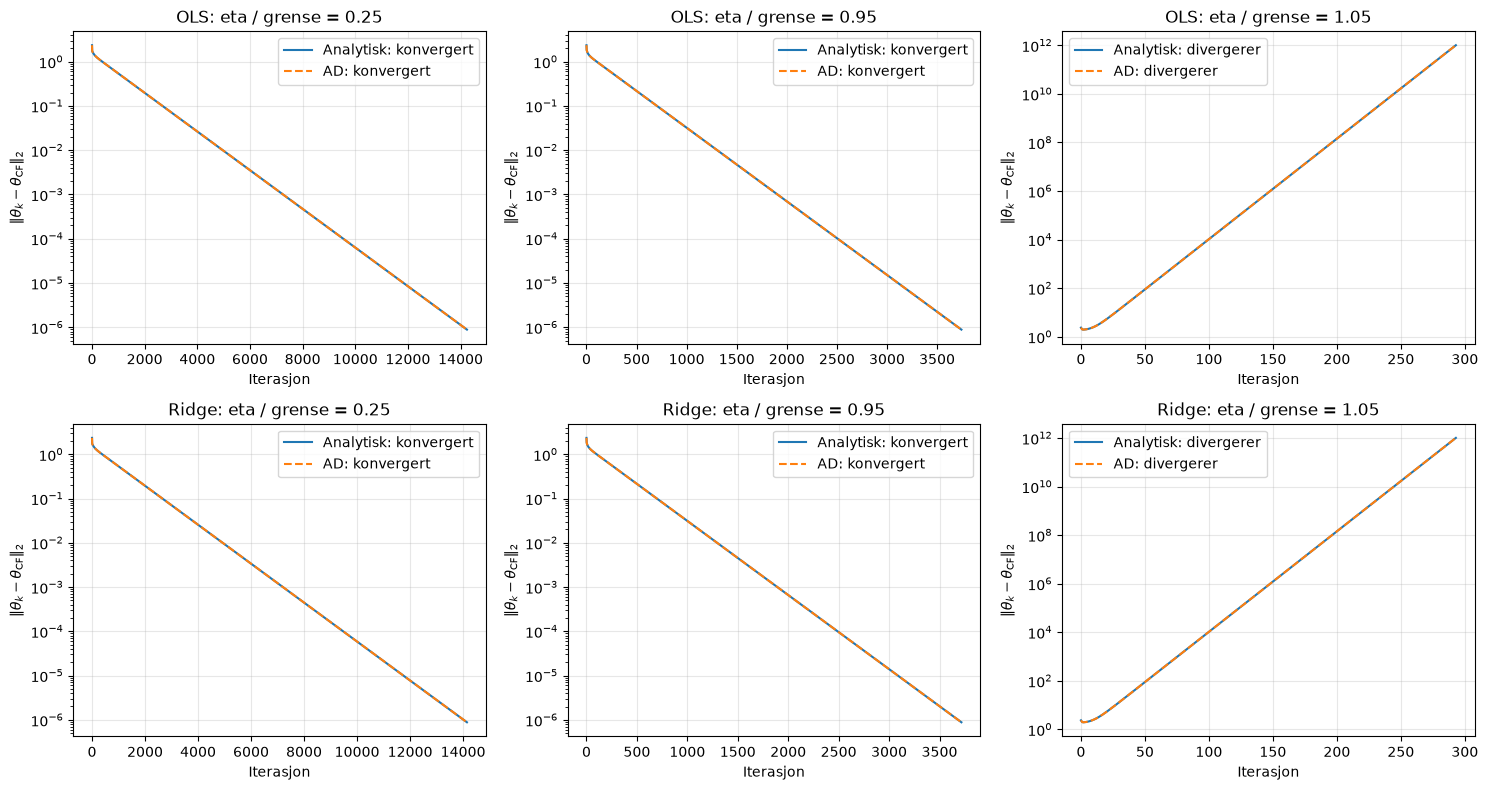

In [11]:
#Tillegg(2)
fig, axes = plt.subplots(
    2, len(fraction), figsize=(15, 8), squeeze=False
)

for row, model_name in enumerate(models_e):
    for col, frac in enumerate(fraction):
        ax = axes[row, col]

        for gradient_name, style in [
            ("Analytisk", "-"),
            ("AD", "--"),
        ]:
            run = runs_e[(model_name, float(frac), gradient_name)]
            parameter_error = np.linalg.norm(
                run["history"] - run["reference"], axis=1
            )

            ax.semilogy(
                np.maximum(parameter_error, np.finfo(float).tiny),
                linestyle=style,
                label=f"{gradient_name}: {run['status']}",
            )

        ax.set(
            title=f"{model_name}: eta / grense = {frac:g}",
            xlabel="Iterasjon",
            ylabel=r"$\|\theta_k-\theta_{\mathrm{CF}}\|_2$",
        )
        ax.grid(alpha=0.3)
        ax.legend()

fig.tight_layout()
plt.show()


# f: Momentum, Adagrad, RMSprop and Adam

In [12]:
def optimiser_step(method, theta, grad, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    """One update of theta from the gradient g at step t = 1, 2, ...; state carries the running quantities."""
    if method == "plain":                                    # Eq. (4.10)
        return theta - gamma * grad, state
    if method == "momentum":                                 # Eq. (4.28)
        v = state.get("v", np.zeros_like(grad))
        state["v"] = v = beta * v + gamma * grad
        return theta - v, state
    if method == "adagrad":                                  # Eqs. (4.42) and (4.45)
        r_o = state.get("r", np.zeros_like(grad))
        state["r"] = r = r_o + grad**2                           # Hvordan initialiserer jeg? 0 skal tilsvare r_0 
        return theta - (gamma/np.sqrt(eps + r))*grad, state
    if method == "rmsprop":                                  # Eqs. (4.47) and (4.48)
        r_o = state.get("r", np.zeros_like(grad))
        state["r"] = r = rho*r_o + (1-rho)*grad**2              # 0 tilsvarer r_0
        return theta - (gamma/np.sqrt(eps + r))*grad, state
    if method == "adam":                                     # Eqs. (4.51), (4.52), (4.54), (4.55)
        m_o = state.get("m", np.zeros_like(grad))
        r_o = state.get("r", np.zeros_like(grad))
        state["m"] = m = beta1*m_o + (1 - beta1)*grad
        state["r"] = r = beta2*r_o + (1- beta2)*grad**2
        m_hat, r_hat = m/(1 - beta1**t), r/(1 - beta2**t)
        return theta - (gamma/(np.sqrt(r_hat) + eps))*m_hat, state
    raise ValueError(f"unknown method {method}")

#ENDRET(6)
def optimise(
    method, theta0, grad, gamma, num_iters=10000, tol=1e-8,
    theta_ref=None, parameter_tol=1e-8, **kw
):
    """Returner historikk, antall oppdateringer og sluttstatus.

    Med theta_ref: stopp når parameter-MSE <= parameter_tol.
    Uten theta_ref: stopp når gradientnorm <= tol.
    """
    theta = np.array(theta0, dtype=float, copy=True)
    state = {}
    history = [theta.copy()]

    # Kontroller også tilstanden etter siste tillatte oppdatering.
    for step in range(num_iters + 1):
        g = np.asarray(grad(theta))

        if (
            not np.all(np.isfinite(theta))
            or not np.all(np.isfinite(g))
            or np.linalg.norm(theta) > 1e12
        ):
            return np.asarray(history), step, "divergerer"

        if theta_ref is not None:
            parameter_mse = np.mean((theta - theta_ref)**2)
            if parameter_mse <= parameter_tol:
                return np.asarray(history), step, "mål nådd"
        elif np.linalg.norm(g) <= tol:
            return np.asarray(history), step, "konvergert"

        if step == num_iters:
            return np.asarray(history), step, "maks iterasjoner"

        theta, state = optimiser_step(
            method, theta, g, state, step + 1, gamma, **kw
        )
        history.append(theta.copy())


In [41]:
def cost(theta, X, y, lmbda=0.0):
    return (
        jnp.mean((y - X @ theta)**2)
        + (lmbda / len(y)) * jnp.sum(theta[1:]**2)
    )
method_list = ["plain", "momentum", "adagrad", "rmsprop", "adam"]

# Deriver med hensyn på theta.
cost_grad = jax.jit(jax.grad(cost, argnums=0))

grad_OLS = lambda theta: np.asarray(
    cost_grad(theta, Xj_e, yj_e)
)
grad_Ridge = lambda theta: np.asarray(
    cost_grad(theta, Xj_e, yj_e, lmbda=lmb_e)
)
Cf_OLS = closed_form(Xj_e, yj_e)
print("Analytisk OLS:", closed_form(Xj_e, yj_e))

Cf_R = closed_form(Xj_e, yj_e, lmb_e)
print("Analytisk Ridge:", closed_form(Xj_e, yj_e, lmb_e))

from time import perf_counter

#Tillegg(3)
rate_factors_f = [0.1, 0.3, 1.0, 3.0]
parameter_target_f = 1e-8
max_steps_f = 10000
timing_repeats_f = 3

# Referanseverdier fra det opprinnelige eksperimentet.
# Verdiene for momentum og Adam er forsøksverdier;
# GD-formlene gir ikke optimale læringsrater for disse metodene.
base_rates_f = {
    "OLS": {
        "plain": eta_lim_O * 0.95,
        "momentum": eta_lim_O * 0.95,
        "adagrad": 0.1,
        "rmsprop": 0.1,
        "adam": best_eta_O,
    },
    "Ridge": {
        "plain": eta_lim_R * 0.95,
        "momentum": eta_lim_R * 0.95,
        "adagrad": 0.1,
        "rmsprop": 0.1,
        "adam": best_eta_R,
    },
}

models_f = {
    "OLS": (grad_OLS, Cf_OLS),
    "Ridge": (grad_Ridge, Cf_R),
}

#ENDRET(7)
# NumPy-konverteringen inne i gradientfunksjonene venter på JAX.
# Disse kallene kompilerer før tidtakingen starter.
grad_OLS(start_e)
grad_Ridge(start_e)

runs_f = {}
rows_f = []

for model_name, (gradient, reference) in models_f.items():
    for method in method_list:
        for factor in rate_factors_f:
            gamma = base_rates_f[model_name][method] * factor
            elapsed_times = []

            for repeat in range(timing_repeats_f):
                begin = perf_counter()

                history, steps, status = optimise(
                    method,
                    start_e,
                    gradient,
                    gamma=gamma,
                    num_iters=max_steps_f,
                    theta_ref=reference,
                    parameter_tol=parameter_target_f,
                )

                elapsed_times.append(perf_counter() - begin)

            median_seconds = float(np.median(elapsed_times))
            parameter_mse = np.mean(
                (history - reference)**2, axis=1
            )
            final_gradient_norm = np.linalg.norm(
                gradient(history[-1])
            )

            runs_f[(model_name, method, factor)] = {
                "history": history,
                "parameter_mse": parameter_mse,
                "steps": steps,
                "status": status,
                "gamma": gamma,
                "seconds": median_seconds,
            }

            rows_f.append({
                "Modell": model_name,
                "Metode": method,
                "Læringsratefaktor": factor,
                "Læringsrate": gamma,
                "Steg": steps,
                "Status": status,
                "Parameter-MSE": parameter_mse[-1],
                "Gradientnorm": final_gradient_norm,
                "Median tid (s)": median_seconds,
                "Median µs/steg": (
                    1e6 * median_seconds / steps
                    if steps > 0 else np.nan
                ),
            })


Analytisk OLS: [ 0.30464391  0.06182422 -0.70568613 -0.23206994  0.51242763  0.17121206]
Analytisk Ridge: [ 0.30464391  0.06121981 -0.70511447 -0.23035306  0.51185432  0.17002147]


In [39]:
#Tillegg(4)
results_f = pd.DataFrame(rows_f)

# Alle forsøkte læringsrater, inkludert mislykkede kjøringer.
for model_name in models_f:
    print(f"\n{model_name}: alle forsøk")
    display(
        results_f[results_f["Modell"] == model_name]
        .reset_index(drop=True)
    )

# Færrest steg til målet blant de undersøkte læringsratene.
successful_f = results_f[
    results_f["Status"] == "mål nådd"
]

best_f = (
    successful_f
    .sort_values(["Steg", "Parameter-MSE"])
    .drop_duplicates(["Modell", "Metode"])
    .reset_index(drop=True)
)

print("\nFærrest steg til målet blant undersøkte læringsrater:")
display(best_f)

for model_name in models_f:
    for method in method_list:
        reached = successful_f[
            (successful_f["Modell"] == model_name)
            & (successful_f["Metode"] == method)
        ]
        if reached.empty:
            print(
                f"{model_name}, {method}: ingen undersøkte "
                "læringsrater nådde målet innen iterasjonsgrensen."
            )



OLS: alle forsøk


,Modell,Metode,Læringsratefaktor,Læringsrate,Steg,Status,Parameter-MSE,Gradientnorm,Median tid (s),Median µs/steg
0,OLS,plain,0.1,0.033889,10000,maks iterasjoner,1.745050e-04,3.648189e-04,1.570360,157.036010
1,OLS,plain,0.3,0.101667,7591,mål nådd,9.979425e-09,2.758838e-06,1.104378,145.485147
2,OLS,plain,1.0,0.338890,2274,mål nådd,9.998569e-09,2.761483e-06,0.258874,113.840814
3,OLS,plain,3.0,1.016670,19,divergerer,3.263070e+24,2.480755e+13,0.002674,140.743000
4,OLS,momentum,0.1,0.033889,2202,mål nådd,9.997777e-09,2.761373e-06,0.249675,113.385470
5,OLS,momentum,0.3,0.101667,677,mål nådd,9.798098e-09,2.733659e-06,0.079577,117.543936
6,OLS,momentum,1.0,0.338890,160,mål nådd,6.359031e-09,9.309147e-04,0.018040,112.749244
7,OLS,momentum,3.0,1.016670,22,divergerer,2.657552e+23,7.079646e+12,0.003360,152.705636
8,OLS,adagrad,0.1,0.100000,10000,maks iterasjoner,2.997494e-03,1.512903e-03,1.207693,120.769291
9,OLS,adagrad,0.3,0.300000,7121,mål nådd,9.987096e-09,2.760979e-06,0.859194,120.656316



Ridge: alle forsøk


,Modell,Metode,Læringsratefaktor,Læringsrate,Steg,Status,Parameter-MSE,Gradientnorm,Median tid (s),Median µs/steg
0,Ridge,plain,0.1,0.033888,10000,maks iterasjoner,1.646393e-04,3.569220e-04,1.091458,109.145756
1,Ridge,plain,0.3,0.101665,7535,mål nådd,9.984750e-09,2.779554e-06,0.811910,107.751802
2,Ridge,plain,1.0,0.338885,2258,mål nådd,9.942560e-09,2.773676e-06,0.236409,104.698203
3,Ridge,plain,3.0,1.016655,19,divergerer,3.263068e+24,2.480790e+13,0.002415,127.096684
4,Ridge,momentum,0.1,0.033888,2186,mål nådd,9.939127e-09,2.773197e-06,0.266554,121.936929
5,Ridge,momentum,0.3,0.101665,671,mål nådd,9.887302e-09,2.765957e-06,0.077693,115.786152
6,Ridge,momentum,1.0,0.338885,160,mål nådd,6.604369e-09,9.308734e-04,0.017585,109.906481
7,Ridge,momentum,3.0,1.016655,22,divergerer,2.657551e+23,7.079747e+12,0.003999,181.770909
8,Ridge,adagrad,0.1,0.100000,10000,maks iterasjoner,2.887254e-03,1.495576e-03,1.235981,123.598087
9,Ridge,adagrad,0.3,0.300000,7069,mål nådd,9.985316e-09,2.780725e-06,0.865745,122.470610



Færrest steg til målet blant undersøkte læringsrater:


,Modell,Metode,Læringsratefaktor,Læringsrate,Steg,Status,Parameter-MSE,Gradientnorm,Median tid (s),Median µs/steg
0,OLS,momentum,1.0,0.338890,160,mål nådd,6.359031e-09,0.000931,0.018040,112.749244
1,Ridge,momentum,1.0,0.338885,160,mål nådd,6.604369e-09,0.000931,0.017585,109.906481
2,Ridge,adam,1.0,1.000000,294,mål nådd,8.959624e-09,0.000003,0.042027,142.949133
3,OLS,adam,1.0,1.000000,296,mål nådd,9.042567e-09,0.000003,0.041635,140.659152
4,Ridge,plain,1.0,0.338885,2258,mål nådd,9.942560e-09,0.000003,0.236409,104.698203
5,OLS,plain,1.0,0.338890,2274,mål nådd,9.998569e-09,0.000003,0.258874,113.840814
6,Ridge,adagrad,1.0,1.000000,3213,mål nådd,9.960665e-09,0.000003,0.405797,126.298402
7,OLS,adagrad,1.0,1.000000,3237,mål nådd,9.948167e-09,0.000003,0.518933,160.313071


OLS, rmsprop: ingen undersøkte læringsrater nådde målet innen iterasjonsgrensen.
Ridge, rmsprop: ingen undersøkte læringsrater nådde målet innen iterasjonsgrensen.


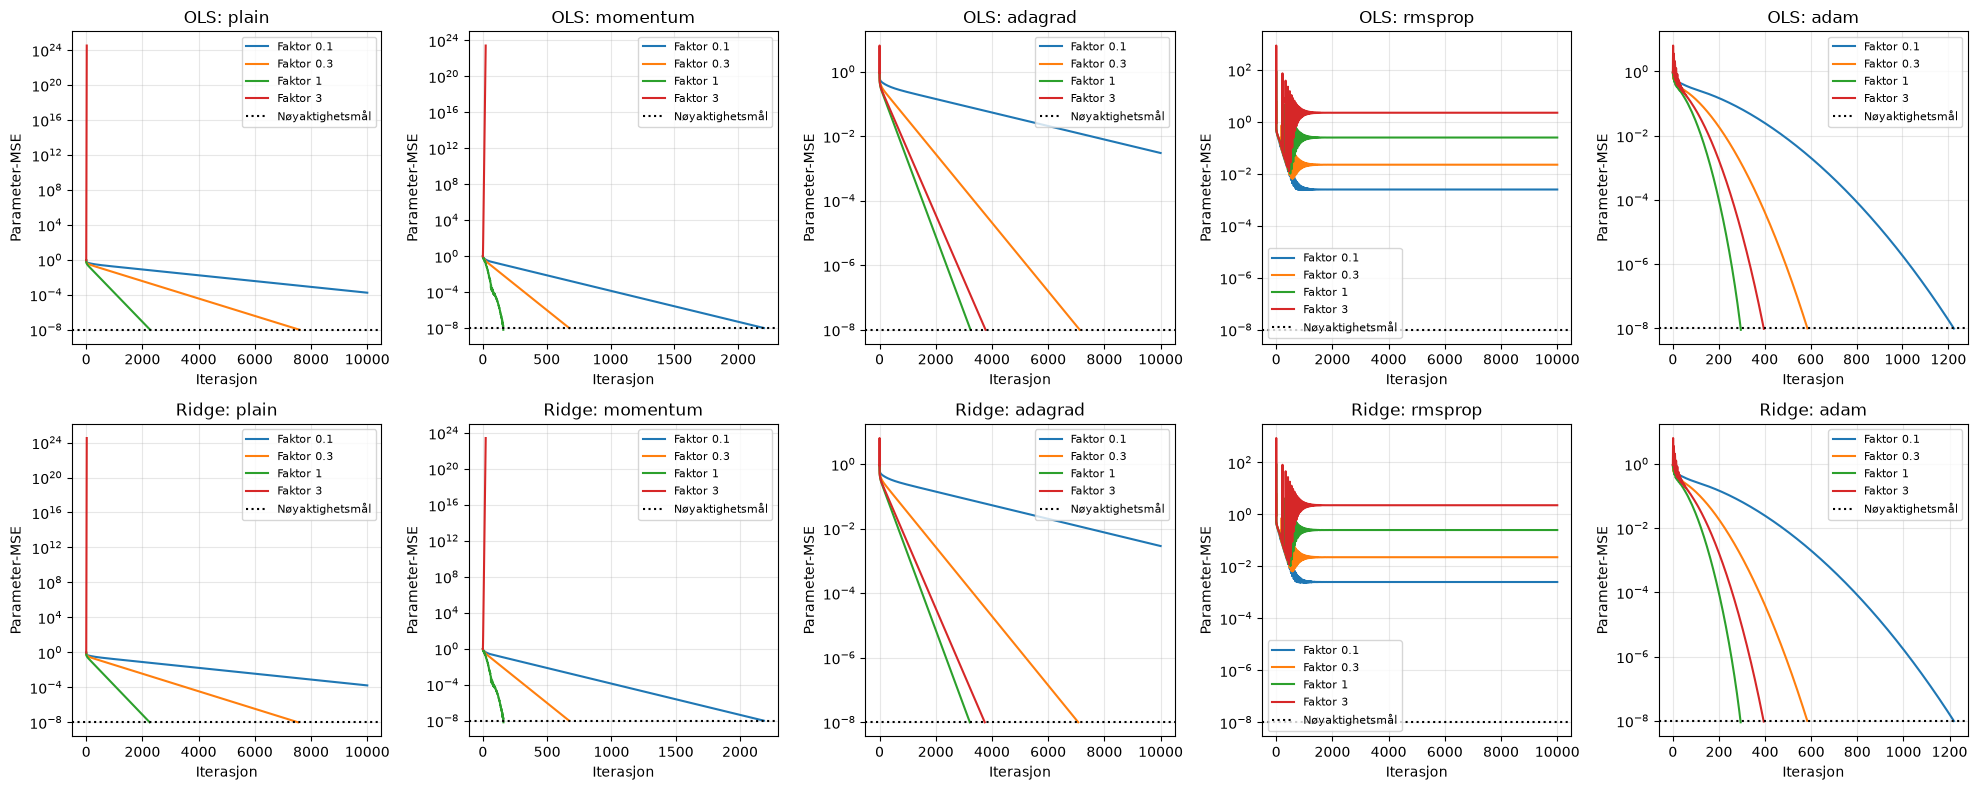

In [40]:
#ENDRET(8)
fig, axes = plt.subplots(
    2, len(method_list),
    figsize=(20, 8),
    squeeze=False,
)

for row, model_name in enumerate(models_f):
    for col, method in enumerate(method_list):
        ax = axes[row, col]

        for factor in rate_factors_f:
            run = runs_f[(model_name, method, factor)]

            ax.semilogy(
                np.maximum(
                    run["parameter_mse"],
                    np.finfo(float).tiny,
                ),
                label=f"Faktor {factor:g}",
            )

        ax.axhline(
            parameter_target_f,
            color="black",
            linestyle=":",
            label="Nøyaktighetsmål",
        )
        ax.set(
            title=f"{model_name}: {method}",
            xlabel="Iterasjon",
            ylabel="Parameter-MSE",
        )
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

fig.tight_layout()
plt.show()


# g: Lasso with gradient descent

In [16]:
#ENDRET(9)
lmb_g = 0.01

def cost_lasso_g(theta, X, y, lmb):
    """MSE + L1-straff på alle koeffisienter unntatt konstantleddet."""
    return (
        np.mean((X @ theta - y)**2)
        + lmb * np.sum(np.abs(theta[1:]))
    )

def gradient_lasso_g(theta):
    """Analytisk subgradient av Lasso-kostnaden på treningsdata fra e.

    Ved theta_j = 0 velger vi subgradienten 0 fra intervallet [-1, 1].
    Konstantleddet får bare bidrag fra MSE-leddet.
    """
    # Gradient av MSE-leddet.
    gradient = (
        2.0 / len(ye_train)
        * Xe_train.T @ (Xe_train @ theta - ye_train)
    )

    # sign(0) = 0: ett gyldig valg av subgradient ved null.
    penalty = np.sign(theta)
    penalty[0] = 0.0

    return gradient + lmb_g * penalty

# AD-kontroll: abs har vanlig derivert utenfor null, men ikke ved null.
# JAX-resultatet ved null er gyldig som subgradient hvis det ligger i [-1, 1].
# Optimaliseringen nedenfor bruker np.sign, ikke JAX-subgradienten.
print("jax.grad(jnp.abs)(0.0) =", jax.grad(jnp.abs)(0.0))
print(
    "jax.grad(jnp.abs)(-0.3) =", jax.grad(jnp.abs)(-0.3),
    " jax.grad(jnp.abs)(0.3) =", jax.grad(jnp.abs)(0.3),
)
ad_at_zero_g = float(jax.grad(jnp.abs)(0.0))
print("Gyldig subgradient:", -1.0 <= ad_at_zero_g <= 1.0)


jax.grad(jnp.abs)(0.0) = 1.0
jax.grad(jnp.abs)(-0.3) = -1.0  jax.grad(jnp.abs)(0.3) = 1.0
Gyldig subgradient: True


In [17]:
#Tillegg(5)
# Scikit-learn bruker (1 / (2*n)) * SSE + alpha * L1.
# alpha = lmb_g / 2 gir derfor samme minimum som vår kostfunksjon.
reference_model_g = Lasso(
    alpha=lmb_g / 2,
    fit_intercept=True,
    max_iter=100000,
    tol=1e-10,
)

# Konstantkolonnen fjernes fordi Scikit-learn håndterer intercept.
reference_model_g.fit(Xe_train[:, 1:], ye_train)

# Samle intercept og koeffisienter i samme format som vår theta.
theta_reference_g = np.r_[
    reference_model_g.intercept_,
    reference_model_g.coef_,
]

reference_cost_g = cost_lasso_g(
    theta_reference_g, Xe_train, ye_train, lmb_g
)

print("Referansekoeffisienter:", theta_reference_g)
# Et lite dual gap støtter at referanseløsningen ligger nær optimum.
print("Scikit-learn dual gap:", reference_model_g.dual_gap_)


Referansekoeffisienter: [ 0.30464391 -0.00617962 -0.59125031 -0.          0.39698943 -0.        ]
Scikit-learn dual gap: 1.3940420699884493e-11



Læringsratefaktor = 0.1


,Læringsrate,Steg,Status,Parameter-MSE,Kostnadsgap,Test-MSE
Metode,,,,,,
plain,0.001,10000,maks iterasjoner,1.607186e-01,3.031776e-02,0.118707
momentum,0.001,9208,mål nådd,9.977792e-09,1.496388e-07,0.098709
adagrad,0.001,10000,maks iterasjoner,6.594965e-01,2.015021e+00,1.583420
rmsprop,0.001,10000,maks iterasjoner,1.193110e-06,1.433155e-05,0.098831
adam,0.001,7849,mål nådd,9.878669e-09,5.501563e-07,0.098704


Test-MSE, Scikit-learn: 0.09870648874104651


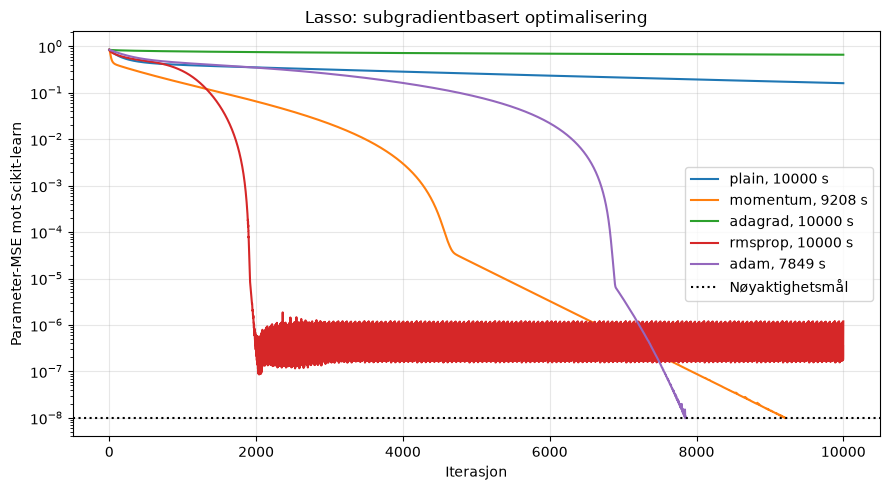


Læringsratefaktor = 0.3


,Læringsrate,Steg,Status,Parameter-MSE,Kostnadsgap,Test-MSE
Metode,,,,,,
plain,0.003,10000,maks iterasjoner,2.128804e-02,7.693451e-03,0.101628
momentum,0.003,3024,mål nådd,9.789402e-09,7.788929e-07,0.098707
adagrad,0.003,10000,maks iterasjoner,4.964237e-01,4.709628e-01,0.418915
rmsprop,0.003,10000,maks iterasjoner,1.884720e-06,5.074411e-05,0.099088
adam,0.003,4588,mål nådd,9.783620e-09,2.065326e-07,0.098708


Test-MSE, Scikit-learn: 0.09870648874104651


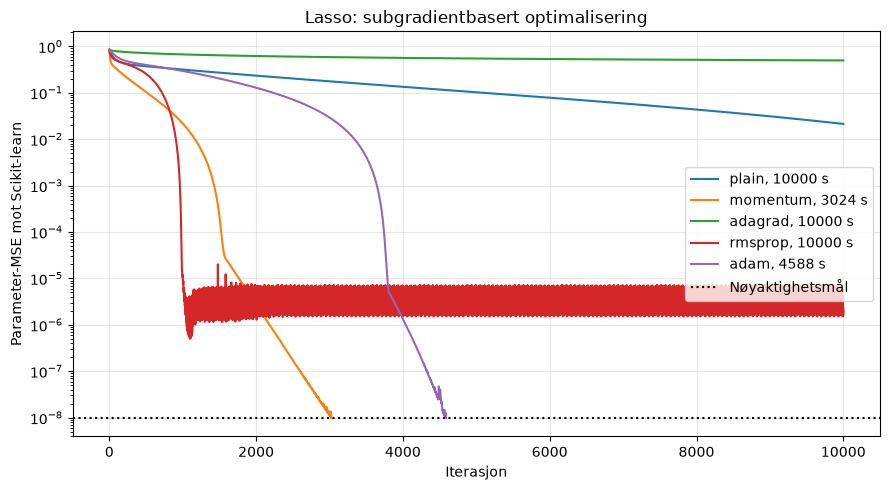


Læringsratefaktor = 1


,Læringsrate,Steg,Status,Parameter-MSE,Kostnadsgap,Test-MSE
Metode,,,,,,
plain,0.01,9322,mål nådd,9.930925e-09,2.009557e-07,0.098705
momentum,0.01,852,mål nådd,9.888123e-09,2.649647e-07,0.098704
adagrad,0.01,10000,maks iterasjoner,3.144326e-01,5.997410e-02,0.143412
rmsprop,0.01,10000,maks iterasjoner,4.344356e-05,5.078536e-04,0.100122
adam,0.01,1943,mål nådd,9.515802e-09,1.398041e-07,0.098706


Test-MSE, Scikit-learn: 0.09870648874104651


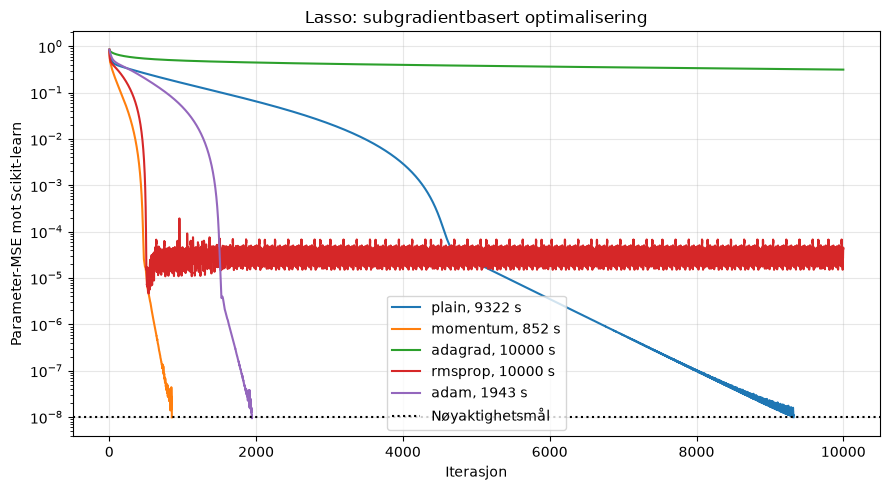


Læringsratefaktor = 3


,Læringsrate,Steg,Status,Parameter-MSE,Kostnadsgap,Test-MSE
Metode,,,,,,
plain,0.03,3442,mål nådd,9.564130e-09,0.000001,0.098703
momentum,0.03,350,mål nådd,1.862684e-09,0.000001,0.098701
adagrad,0.03,10000,maks iterasjoner,3.821075e-02,0.010705,0.102837
rmsprop,0.03,10000,maks iterasjoner,3.040413e-04,0.003339,0.106199
adam,0.03,719,mål nådd,8.104803e-09,0.000001,0.098698


Test-MSE, Scikit-learn: 0.09870648874104651


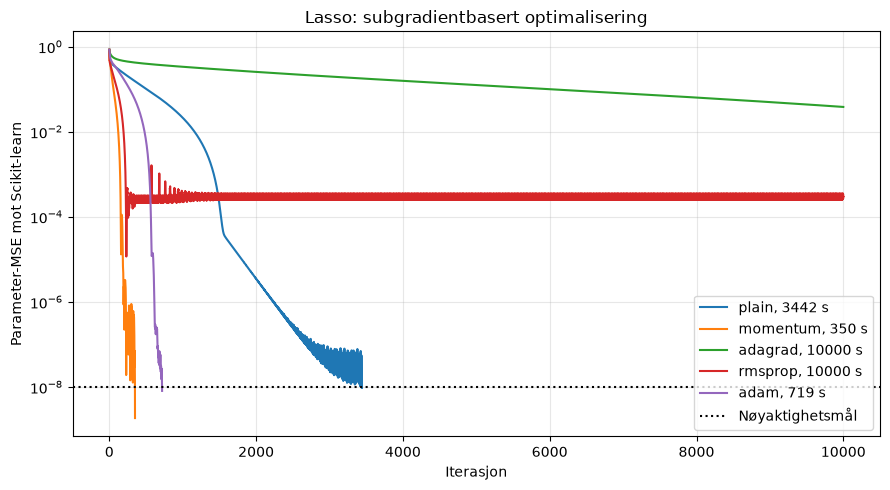


Læringsratefaktor = 10


,Læringsrate,Steg,Status,Parameter-MSE,Kostnadsgap,Test-MSE
Metode,,,,,,
plain,0.1,10000,maks iterasjoner,2.953214e-07,6.841439e-06,0.098745
momentum,0.1,10000,maks iterasjoner,7.144687e-07,1.133254e-05,0.098649
adagrad,0.1,3948,mål nådd,9.678446e-09,7.859311e-07,0.098697
rmsprop,0.1,10000,maks iterasjoner,3.168727e-03,3.457250e-02,0.156548
adam,0.1,1595,mål nådd,5.901845e-09,1.458282e-06,0.098724


Test-MSE, Scikit-learn: 0.09870648874104651


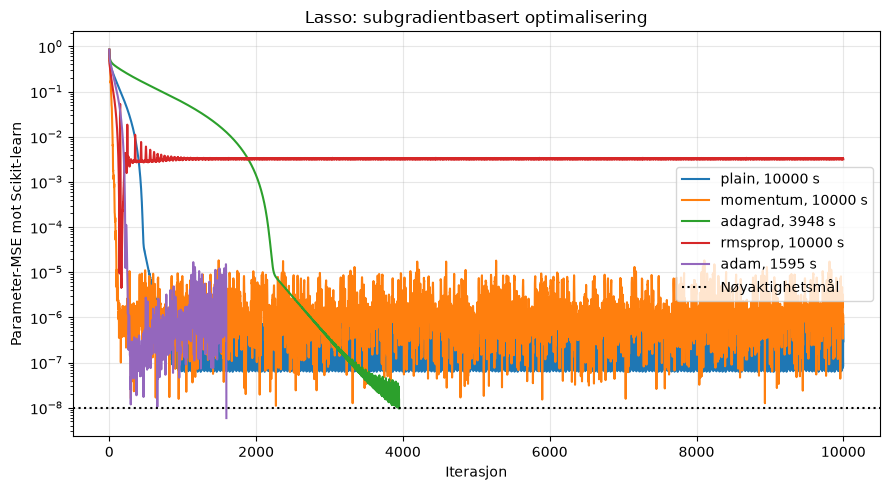

In [47]:
#Tillegg(6)
# Enkle forsøksverdier, ikke optimaliserte læringsrater.
def lasso_rates(rate_factor):
    rates_g = {
        "plain": 0.01*rate_factor,
        "momentum": 0.01*rate_factor,
        "adagrad": 0.01*rate_factor,
        "rmsprop": 0.01*rate_factor,
        "adam": 0.01*rate_factor,
    }

    results_g = []
    histories_g = {}

    for method, gamma in rates_g.items():
        # Gjenbruk oppdateringsreglene fra e/f med Lasso-subgradienten.
        # Referansen brukes bare til stoppkriteriet, ikke til oppdateringene.
        history, steps, status = optimise(
            method,
            start_e,
            gradient_lasso_g,
            gamma=gamma,
            num_iters=10000,
            theta_ref=theta_reference_g,
            parameter_tol=1e-8,
        )

        theta = history[-1]
        histories_g[method] = history

        # Parameterfeil måler avvik fra referansen; test-MSE måler prediksjonsfeil.
        results_g.append({
            "Metode": method,
            "Læringsrate": gamma,
            "Steg": steps,
            "Status": status,
            "Parameter-MSE": np.mean(
                (theta - theta_reference_g)**2
            ),
            "Kostnadsgap": (
                cost_lasso_g(theta, Xe_train, ye_train, lmb_g)
                - reference_cost_g
            ),
            "Test-MSE": np.mean(
                (Xe_test @ theta - ye_test)**2
            ),
        })

    display(pd.DataFrame(results_g).set_index("Metode"))

    print(
        "Test-MSE, Scikit-learn:",
        np.mean((Xe_test @ theta_reference_g - ye_test)**2),
    )
    # Konstant læringsrate kan gi oscillasjoner ved nullkoeffisienter.
    # Maks iterasjoner betyr at nøyaktighetsmålet ikke ble nådd innen budsjettet.

    #Tillegg(7)
    # Logaritmisk y-akse gjør små parameteravvik synlige.
    fig, ax = plt.subplots(figsize=(9, 5))

    for method, history in histories_g.items():
        parameter_mse = np.mean(
            (history - theta_reference_g)**2, axis=1
        )
        method_name = method
        ax.semilogy(
            np.maximum(parameter_mse, np.finfo(float).tiny),
            label=f"{method_name}, {len(history)-1} s"
        )

    ax.axhline(
        1e-8, color="black", linestyle=":",
        label="Nøyaktighetsmål",
    )
    ax.set(
        title="Lasso: subgradientbasert optimalisering",
        xlabel="Iterasjon",
        ylabel="Parameter-MSE mot Scikit-learn",
    )
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()

rate_factor_g = [0.1, 0.3, 1.0, 3.0, 10.0]

for factor in rate_factor_g:
    print(f"\nLæringsratefaktor = {factor:g}")
    lasso_rates(factor)
